# Linear Regression

In [38]:
# Import all required liberies 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
# Import datset
data =pd.read_csv('USA_Housing.csv')

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [76]:
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [77]:
# target price prediction

In [78]:
# Drop Address Column
data.drop(columns=['Address'],inplace=True)

In [79]:
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [80]:
# Area Population convert to Int
data['Area Population']= data['Area Population'].astype('int64')

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   int64  
 5   Price                         5000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 234.5 KB


In [83]:
data.head(10)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354,6.309435e+05
5,80175.754159,4.988408,6.104512,4.04,26748,1.068138e+06
6,64698.463428,6.025336,8.147760,3.41,60828,1.502056e+06
7,78394.339278,6.989780,6.620478,2.42,36516,1.573937e+06
8,59927.660813,5.362126,6.393121,2.30,29387,7.988695e+05
9,81885.927184,4.423672,8.167688,6.10,40149,1.545155e+06


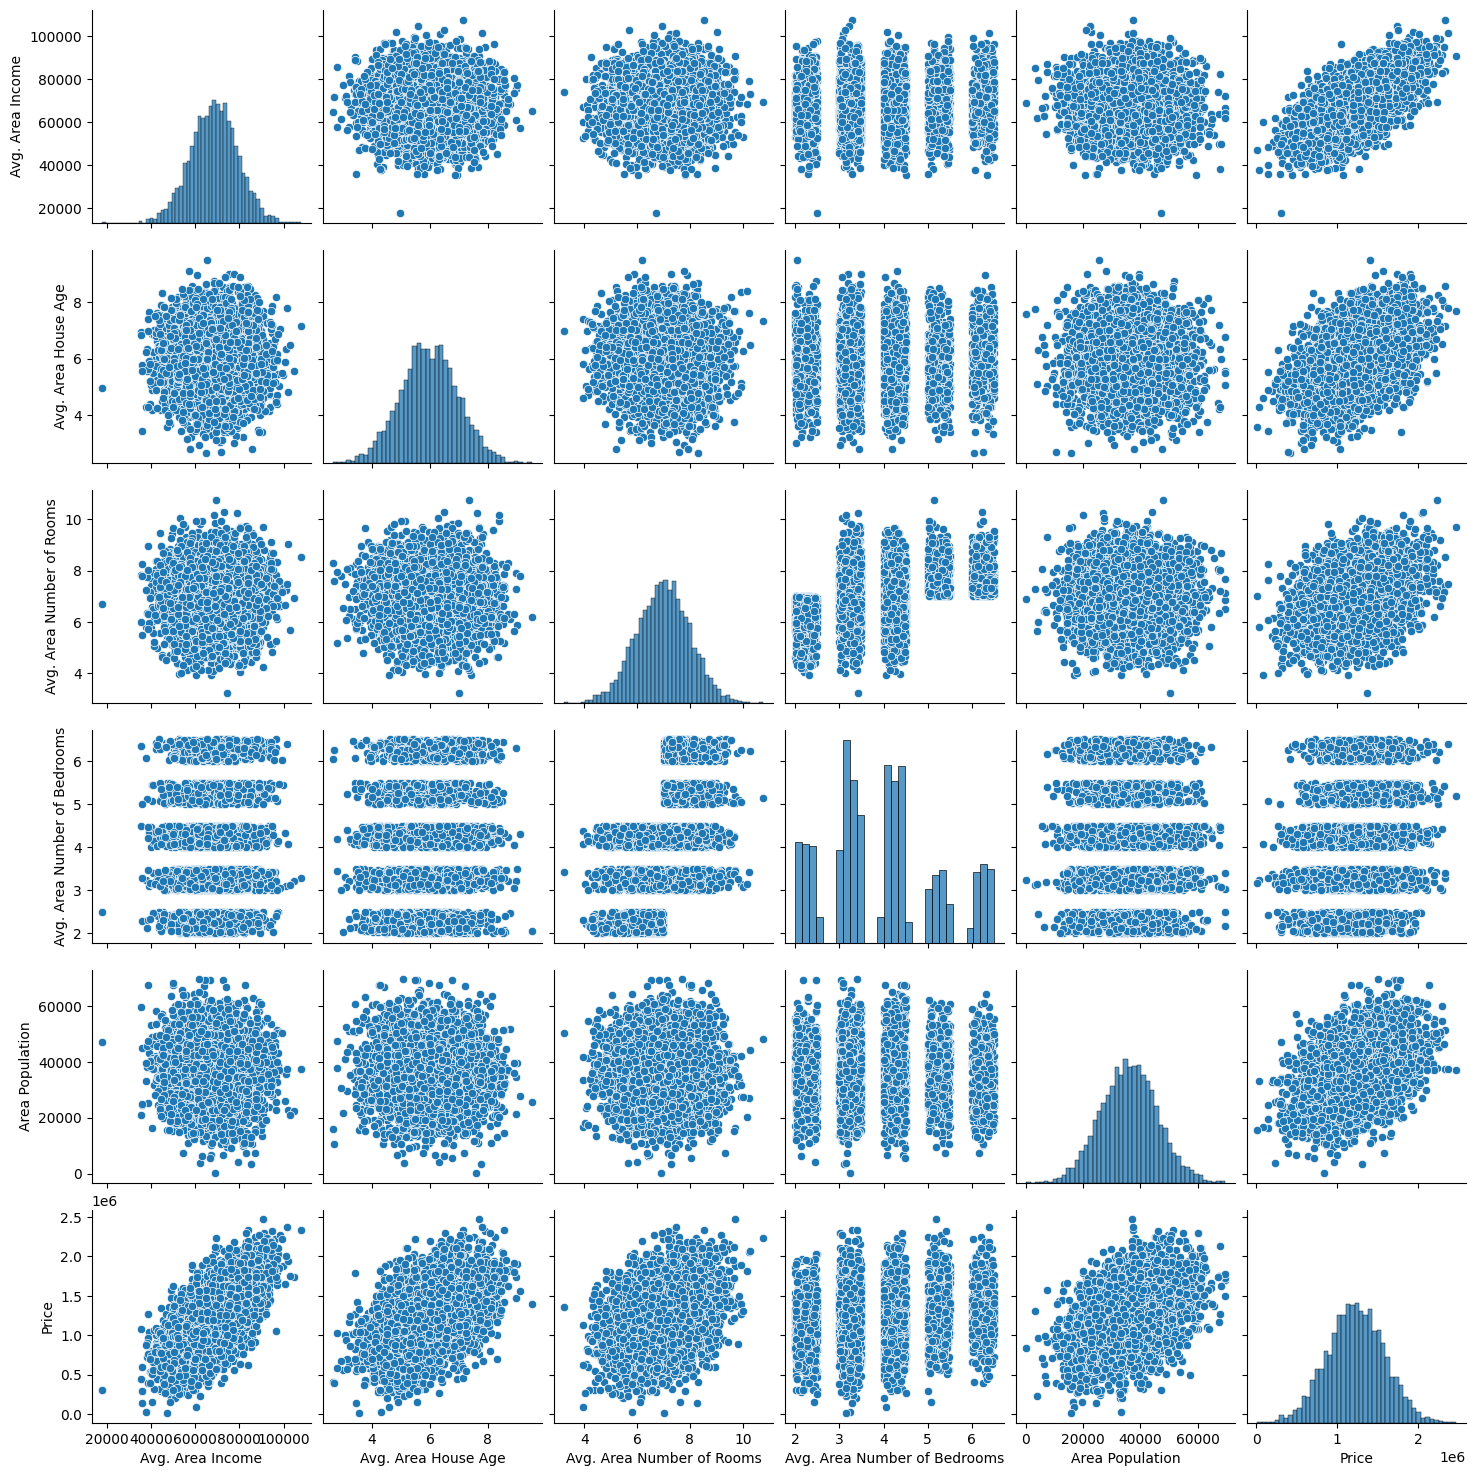

In [84]:
# Draw Pairplot
sns.pairplot(data=data)

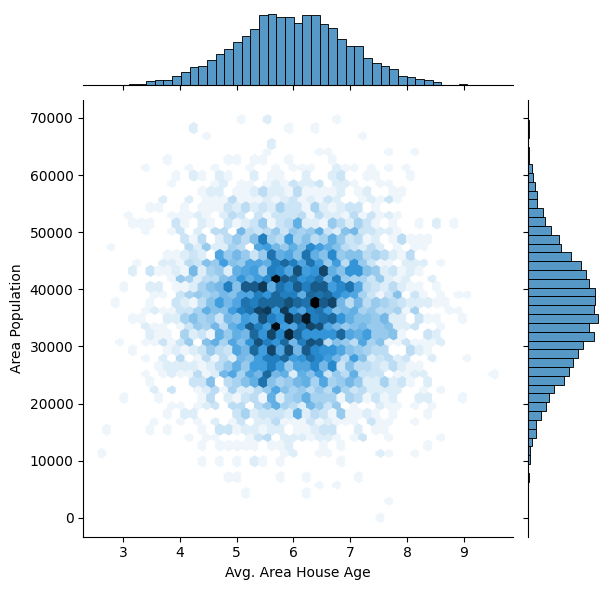

In [85]:
# JointPlot
sns.jointplot(data=data,x='Avg. Area House Age',y='Area Population',kind='hex')

<Axes: >

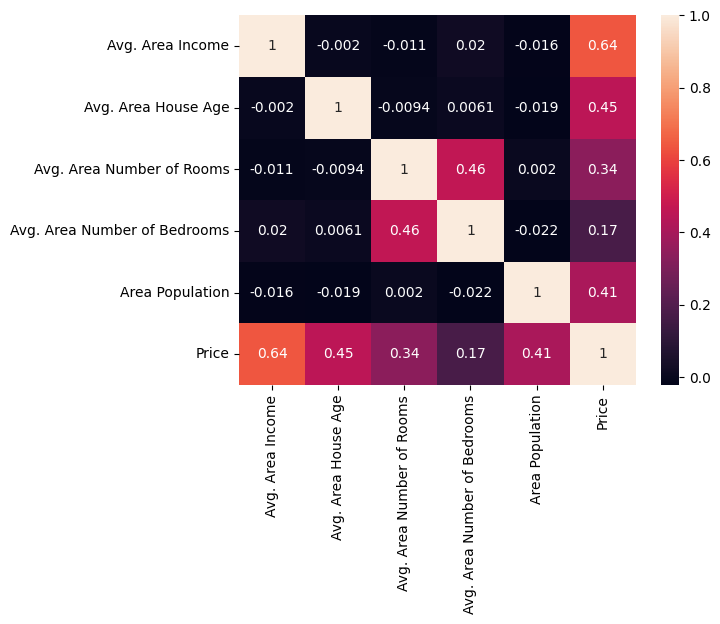

In [86]:
# Heatmap of Correlation
corr=data.corr()
sns.heatmap(corr,annot=True)

In [87]:
# conda install scikit-learn

In [88]:
# Import split part 
from sklearn.model_selection import train_test_split

In [89]:
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354,6.309435e+05


In [90]:
# target =PRice

features= data.drop(columns=['Price'])

In [91]:
features.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086
1,79248.642455,6.002900,6.730821,3.09,40173
2,61287.067179,5.865890,8.512727,5.13,36882
3,63345.240046,7.188236,5.586729,3.26,34310
4,59982.197226,5.040555,7.839388,4.23,26354


In [92]:
target=data['Price']

In [93]:
target.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [94]:
# Split 
# Return X= features , y=target
# X_train, X_test, Y_train, Y_test
X_train, X_test, Y_train, Y_test=train_test_split(features,target,random_state=101,train_size=0.8)

In [95]:
X_train

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
3413,69048.788093,6.619712,6.123813,4.33,36817
1610,67866.899929,5.393978,9.359022,5.44,43122
3459,56636.238191,5.497667,7.121872,6.10,47541
4293,79310.361977,4.247434,7.518204,4.38,43982
1039,72821.247664,6.480819,7.116655,5.33,40594
...,...,...,...,...,...
4171,56610.642563,4.846832,7.558137,3.29,25494
599,70596.850945,6.548274,6.539986,3.10,51614
1361,55621.899104,3.735942,6.868291,2.30,63184
1547,63044.460096,5.935261,5.913454,4.10,32725


In [96]:
X_test

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
1718,66774.995817,5.717143,7.795215,4.32,36788
2511,62184.539375,4.925758,7.427689,6.22,26008
345,73643.057298,6.766853,8.337085,3.34,43152
2521,61909.041438,6.228343,6.593138,4.29,28953
54,72942.705059,4.786222,7.319886,6.41,24377
...,...,...,...,...,...
3900,77615.851343,6.200603,6.909327,2.27,36591
3753,66925.199349,5.153050,8.396903,3.16,42590
3582,71778.026176,5.921280,7.411045,4.00,37634
2392,87272.093393,5.025866,7.184765,5.39,7522


In [61]:
# Y part = Target 

list_of_targets=[1,1,1,1,2,2,2,2,3,3]
# 80% train , 20% testing
# Y_train & Y_test
Y_train=[1,1,1,1,2,2,2,2]
y_test=[3,3]

suffle=[1,2,3,1,1,2,3,2,1,2]

In [62]:
# Example dataframe 
exaple_df=pd.DataFrame(
    {
        'Feature 1':np.arange(1,11),
        'Feature 2': np.arange(2,12),
        'Target': np.arange(3,13)
    }
)
exaple_df

,Feature 1,Feature 2,Target
0,1,2,3
1,2,3,4
2,3,4,5
3,4,5,6
4,5,6,7
5,6,7,8
6,7,8,9
7,8,9,10
8,9,10,11
9,10,11,12


<Axes: xlabel='Feature 1', ylabel='Target'>

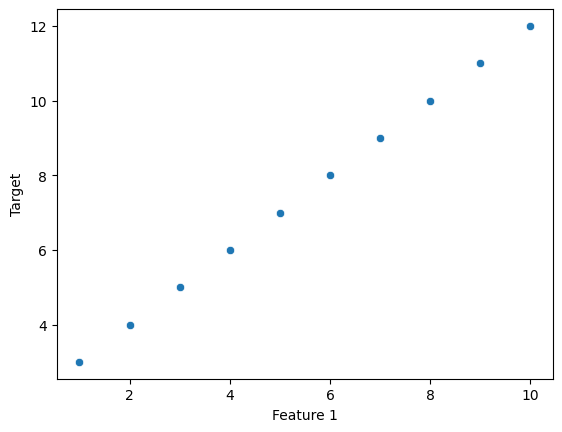

In [63]:
# realtionship between feature 1 & Target
sns.scatterplot(data=exaple_df,x='Feature 1',y='Target')

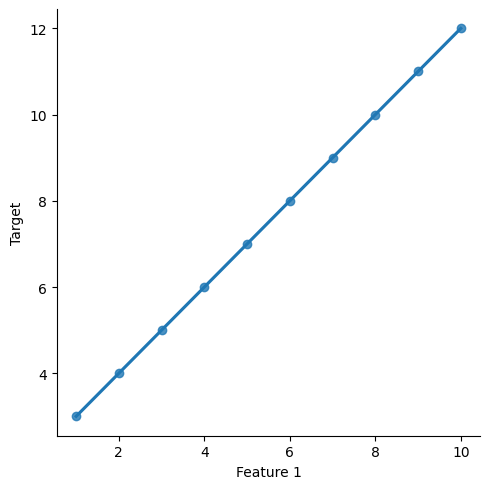

In [64]:
# Linear Moder plot 
sns.lmplot(data=exaple_df,x='Feature 1',y='Target')


In [65]:
# Suffle 
new_col=exaple_df['Target'].copy()

np.random.shuffle(new_col)

C:\Users\masum\AppData\Local\Temp\ipykernel_29484\3933839975.py:4: UserWarning: you are shuffling a 'Series' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(new_col)


In [66]:
exaple_df['Target']=new_col

In [67]:
exaple_df

,Feature 1,Feature 2,Target
0,1,2,7
1,2,3,3
2,3,4,9
3,4,5,12
4,5,6,5
5,6,7,10
6,7,8,4
7,8,9,8
8,9,10,11
9,10,11,6


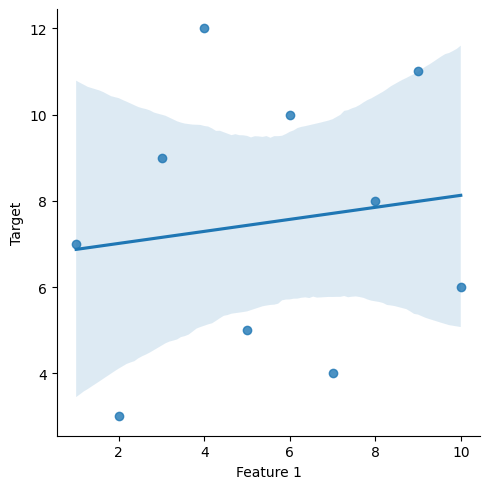

In [97]:
sns.lmplot(data=exaple_df,x='Feature 1',y='Target')

In [69]:
# X_train, X_test, Y_train, Y_test

In [98]:
# Import Linear Regression Model
from sklearn.linear_model import LinearRegression

In [100]:
# Object create of this model 
model =LinearRegression()

In [101]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [102]:
# coefficient value check
model.coef_

array([2.15666979e+01, 1.65453003e+05, 1.20499882e+05, 1.99969855e+03,
       1.53406142e+01])

In [106]:
X_train.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
3413,69048.788093,6.619712,6.123813,4.33,36817
1610,67866.899929,5.393978,9.359022,5.44,43122
3459,56636.238191,5.497667,7.121872,6.10,47541
4293,79310.361977,4.247434,7.518204,4.38,43982
1039,72821.247664,6.480819,7.116655,5.33,40594


In [103]:
pd.DataFrame(
    index=X_train.columns,
    data=model.coef_,
    columns=['coefficient']
)

,coefficient
Avg. Area Income,21.566698
Avg. Area House Age,165453.002657
Avg. Area Number of Rooms,120499.882065
Avg. Area Number of Bedrooms,1999.698546
Area Population,15.340614


In [107]:
model.intercept_

np.float64(-2640433.911356714)

In [109]:
# Prediction
predict =model.predict(X_test)

<Axes: xlabel='Price'>

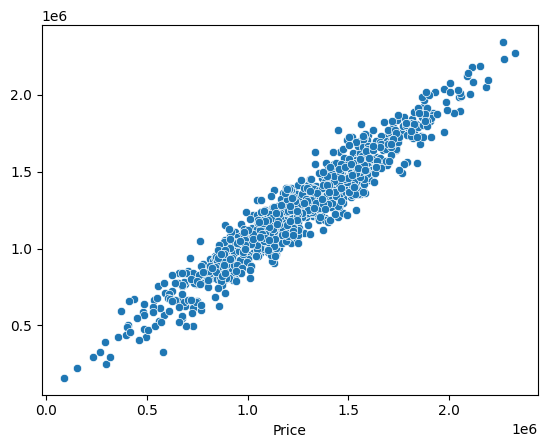

In [110]:
# Scatterplot of prediction
sns.scatterplot(x=Y_test,y=predict)

<Axes: xlabel='Price', ylabel='Count'>

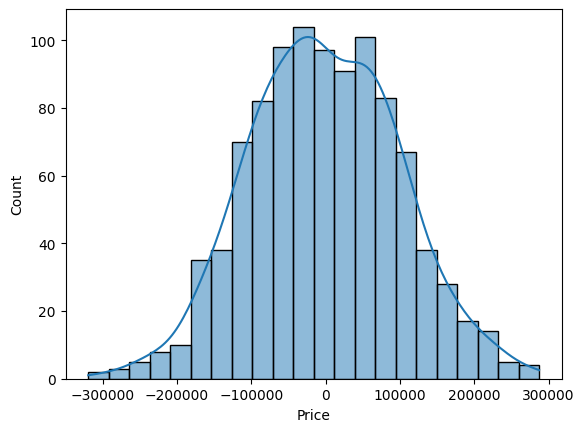

In [111]:
# distubuter plot 
sns.histplot(Y_test-predict,kde=True)

In [112]:
# Evaluate metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [113]:
MAE=mean_absolute_error(Y_test,predict)
MAE

81305.17649078327

In [124]:
MSE=mean_squared_error(Y_test,predict)


In [125]:
RMSE=np.sqrt(MSE)

In [126]:
RMSE

np.float64(100499.69573552307)